# PGNN + Physics-Constraint Pipeline — Al 6011-O Flow Stress
### Honest extrapolation evaluation (LOCO) + non-redundant physics losses + multi-seed ablation

This notebook rebuilds the Al 6011-O PGNN study around three corrections established by analysis of the
original pipeline:

1. **Leakage fix.** The original random within-curve split tests *interpolation* between adjacent points on
   the same stress–strain curve, which inflates R² and hides whether physics helps. Here the headline metric
   is **Leave-One-Condition-Out (LOCO)** — train on 20 conditions, predict an entirely unseen one. The old
   random split is kept only as a reference baseline.
2. **Non-redundant physics losses.** Matching `σ_SCAM` is redundant (the architecture already pushes learned
   parameters through the *same* Arrhenius formula that SCAM uses, and SCAM is fit to the same data). It is
   replaced by physics that the data + formula do **not** already impose:
   - `L_consistency` — Arrhenius parameters (α,n,Q,lnA) depend on strain ε only, not on T or ε̇ (strain-compensated Arrhenius assumption).
   - `L_smooth` — parameters vary smoothly with ε.
   - `L_mono` — σ increases with strain rate and decreases with temperature (thermodynamic monotonicity).
   All are computed on **normalized** parameters / via autograd so every term is O(1).
3. **Statistics.** Every configuration is run over multiple seeds with paired Δ and a t-test, as an ablation:
   baseline → each term alone → pairs → all three. Two weighting modes: fixed-λ and learned uncertainty weighting.

## Table of contents
1. Imports & configuration
2. Reproducibility
3. Data loading
4. Splits — random (reference) and Leave-One-Condition-Out
5. SCAM polynomial (parameter validation + optional legacy term)
6. Per-fold data prep (scalers fit on train only)
7. Model — HybridPGNN (Arrhenius output layer)
8. Physics losses (normalized, autograd) + multi-term weighting
9. Training engine
10. Evaluation helpers
11. Sanity run — random split (reproduce baseline) vs LOCO (honest)
12. LOCO × multi-seed × ablation driver
13. Results tables & figures
14. SCAM parameter validation
15. How to extend / run full study

## 1 · Imports & Configuration

In [1]:
from __future__ import annotations
import copy, math, os, random, time, warnings, itertools
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
warnings.filterwarnings("ignore")
R_GAS = 8.314  # J/(mol K)

@dataclass
class Config:
    # --- paths ---
    data_path: str = "/kaggle/input/datasets/vatine/al-data-downsampled/al6011_downsampled_full.xlsx"  # EDIT to your Kaggle dataset path
    output_dir: str = "."
    # --- data ---
    feature_cols: List[str] = field(default_factory=lambda: ["T_K", "ln_sr", "eps_true"])
    target_col: str = "sigma_true"
    val_ratio: float = 0.15
    # --- model ---
    hidden_dims: List[int] = field(default_factory=lambda: [128, 128, 64])
    dropout: float = 0.1
    # --- training ---
    batch_size: int = 64
    epochs: int = 500
    patience: int = 60
    lr: float = 1e-3
    weight_decay: float = 1e-5
    scheduler_factor: float = 0.5
    scheduler_patience: int = 30
    grad_clip: float = 10.0
    # --- physics ---
    scam_temp_min_K: float = 523.0          # 250 C
    scam_eps_min: float = 0.05
    scam_eps_max: float = 0.19              # SCAM valid strain window
    smooth_eps_grid: Tuple[float,float,int] = (0.05, 0.65, 60)  # grid for L_smooth
    # --- experiment control ---
    seed: int = 42
    seeds: List[int] = field(default_factory=lambda: [42, 1, 2])  # multi-seed; add more for final
    quick: bool = False   # True = fast smoke run (few epochs, subset of folds). Set False for full study.
    @property
    def device(self): return torch.device("cuda" if torch.cuda.is_available() else "cpu")

CFG = Config()
if CFG.quick:
    CFG.epochs =  10 # fast pass to verify everything runs end-to-end
print("Device:", CFG.device, "| epochs:", CFG.epochs, "| quick:", CFG.quick, "| seeds:", CFG.seeds)

Device: cuda | epochs: 500 | quick: False | seeds: [42, 1, 2]


## 2 · Reproducibility

In [2]:
def seed_everything(seed: int = None) -> None:
    seed = CFG.seed if seed is None else seed
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

## 3 · Data Loading

In [3]:
def _find_data_path(p: str) -> str:
    if os.path.exists(p): return p
    for root in ["/kaggle/input", "."]:
        for dp, _, fns in os.walk(root):
            for fn in fns:
                if fn == os.path.basename(p): return os.path.join(dp, fn)
    raise FileNotFoundError(f"Could not locate {p}")

CFG.data_path = _find_data_path(CFG.data_path)
xf = pd.ExcelFile(CFG.data_path)
sheets = [s for s in xf.sheet_names if s != "Summary"]
data = pd.concat([pd.read_excel(CFG.data_path, sheet_name=s).assign(condition=s) for s in sheets],
                 ignore_index=True)
print(f"Loaded {len(data):,} points | {data['condition'].nunique()} conditions")

X_all   = data[CFG.feature_cols].values.astype(np.float32)
y_all   = data[CFG.target_col].values.astype(np.float32).reshape(-1, 1)
T_K_raw = data["T_K"].values.astype(np.float32)
sr_raw  = data["strain_rate"].values.astype(np.float32)
eps_raw = data["eps_true"].values.astype(np.float32)
cond_arr= data["condition"].values
ALL_CONDS = list(data["condition"].unique())

Loaded 1,982 points | 21 conditions


## 4 · Splits — Random (reference) and Leave-One-Condition-Out (honest)

`random_split` reproduces the original within-condition shuffle (interpolation — optimistic).
`loco_split` holds out one entire condition (extrapolation — the metric that actually tests generalization).
A held-out *temperature* or *strain-rate* variant is also provided for harder extrapolation.

In [4]:
def random_split(seed=CFG.seed, train_ratio=0.70, val_ratio=CFG.val_ratio):
    rng = np.random.default_rng(seed)
    tr, va, te = [], [], []
    for c in ALL_CONDS:
        idx = np.where(cond_arr == c)[0].copy(); rng.shuffle(idx)
        n = len(idx); ntr = int(train_ratio*n); nva = int(val_ratio*n)
        tr += list(idx[:ntr]); va += list(idx[ntr:ntr+nva]); te += list(idx[ntr+nva:])
    return np.array(tr), np.array(va), np.array(te)

def loco_split(holdout_condition, seed=CFG.seed, val_ratio=CFG.val_ratio):
    rng = np.random.default_rng(seed)
    te = np.where(cond_arr == holdout_condition)[0]
    pool = np.where(cond_arr != holdout_condition)[0].copy(); rng.shuffle(pool)
    nva = int(val_ratio*len(pool))
    return pool[nva:], pool[:nva], te

def loto_split(holdout_T_C, seed=CFG.seed, val_ratio=CFG.val_ratio):
    """Leave-one-temperature-out (harder)."""
    rng = np.random.default_rng(seed)
    te = np.where(data["T_C"].values == holdout_T_C)[0]
    pool = np.where(data["T_C"].values != holdout_T_C)[0].copy(); rng.shuffle(pool)
    nva = int(val_ratio*len(pool))
    return pool[nva:], pool[:nva], te

## 5 · SCAM Polynomial (parameter validation + optional legacy term)

SCAM is **not** used as the main physics target (redundant). It is kept to (a) reproduce the legacy
`L_scam` term for the ablation comparison and (b) validate learned parameters against a classical fit.
Coefficients below are the user's fitted polynomials; they are physically sane inside ε∈[0.05,0.19].

In [5]:
SCAM_POLY_COEFFS = {
 "alpha": np.array([ 2.990838465670e+04,-1.994069281431e+04, 5.345762450621e+03,-7.350303313298e+02,
                     5.448368675032e+01,-2.063309588944e+00, 5.051186723984e-02]),
 "n":     np.array([-7.812215710077e+05, 2.343228580944e+05, 4.087839767037e+04,-2.591299218747e+04,
                     4.249708974788e+03,-3.168428320818e+02, 1.508120816407e+01]),
 "Q":     np.array([-8.543584880384e+10, 5.238248618259e+10,-1.249643528684e+10, 1.436699072794e+09,
                    -7.644242300049e+07, 1.055736379502e+06, 1.900591723054e+05]),
 "lnA":   np.array([-2.689844217277e+07, 1.687345535442e+07,-4.163261535534e+06, 5.066408364188e+05,
                    -3.055325125124e+04, 7.305787733034e+02, 2.523144522408e+01]),
}
def scam_sigma_np(eps, T_K, sr):
    a=np.polyval(SCAM_POLY_COEFFS["alpha"],eps); n=np.polyval(SCAM_POLY_COEFFS["n"],eps)
    Q=np.polyval(SCAM_POLY_COEFFS["Q"],eps);     lnA=np.polyval(SCAM_POLY_COEFFS["lnA"],eps)
    Z = sr*np.exp(Q/(R_GAS*T_K))
    return (1.0/a)*np.arcsinh((Z/np.exp(lnA))**(1.0/n))

# precompute SCAM target + validity mask once (used only if 'scam' term is active)
_scam_raw = scam_sigma_np(eps_raw, T_K_raw, sr_raw).astype(np.float64)
SCAM_VALID = (np.isfinite(_scam_raw) & (T_K_raw >= CFG.scam_temp_min_K)
              & (eps_raw >= CFG.scam_eps_min) & (eps_raw <= CFG.scam_eps_max))
_scam_raw[~SCAM_VALID] = 0.0
SCAM_SIGMA = np.clip(_scam_raw, 0, 500).astype(np.float32).reshape(-1,1)
print(f"SCAM valid points: {SCAM_VALID.sum()}/{len(SCAM_VALID)} ({100*SCAM_VALID.mean():.1f}%)")

SCAM valid points: 435/1982 (21.9%)


## 6 · Per-fold Data Prep (scalers fit on train only — no leakage)

Scalers are re-fit for **every** split/fold on that fold's training points. Returns a small bundle of
tensors plus the fitted scalers and a scaled ε-grid for the smoothness term.

In [6]:
@dataclass
class Fold:
    tr: np.ndarray; va: np.ndarray; te: np.ndarray
    sx: StandardScaler; sy: StandardScaler
    smooth_grid: torch.Tensor   # (G,3) scaled features for L_smooth
    device: torch.device

def prep_fold(tr, va, te) -> Fold:
    sx = StandardScaler().fit(X_all[tr]); sy = StandardScaler().fit(y_all[tr])
    lo, hi, g = CFG.smooth_eps_grid
    eg = np.linspace(lo, hi, g).astype(np.float32)
    # representative hot condition for the smoothness grid (T=723K, sr=0.01)
    grid_raw = np.stack([np.full_like(eg, 723.15), np.full_like(eg, np.log(0.01)), eg], 1)
    grid = torch.tensor(sx.transform(grid_raw).astype(np.float32), device=CFG.device)
    return Fold(tr, va, te, sx, sy, grid, CFG.device)

def make_loader(F: Fold, idx, shuffle):
    t = (torch.tensor(F.sx.transform(X_all[idx]).astype(np.float32)),
         torch.tensor(((y_all[idx]-F.sy.mean_[0])/F.sy.scale_[0]).astype(np.float32)),
         torch.tensor(T_K_raw[idx].reshape(-1,1)), torch.tensor(sr_raw[idx].reshape(-1,1)),
         torch.tensor(eps_raw[idx].reshape(-1,1)),
         torch.tensor(((SCAM_SIGMA[idx]-F.sy.mean_[0])/F.sy.scale_[0]).astype(np.float32)),
         torch.tensor(SCAM_VALID[idx].astype(np.float32).reshape(-1,1)))
    bs = CFG.batch_size if shuffle else 256
    return DataLoader(TensorDataset(*t), batch_size=bs, shuffle=shuffle)

## 7 · Model — HybridPGNN (Arrhenius output layer)

In [7]:
PARAM_BOUNDS = {"alpha": (0.005, 0.045), "n": (2.0, 8.0), "Q": (130_000, 90_000), "lnA": (15.0, 25.0)}

class HybridPGNN(nn.Module):
    def __init__(self, input_dim=3, hidden_dims=None, dropout=CFG.dropout):
        super().__init__()
        hidden_dims = hidden_dims or CFG.hidden_dims
        layers, d = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]; d = h
        self.backbone = nn.Sequential(*layers)
        self.heads = nn.ModuleDict({k: nn.Linear(hidden_dims[-1], 1) for k in PARAM_BOUNDS})

    def raw_params(self, x_scaled):
        """Normalized params in [0,1] (sigmoid outputs) — used by physics losses (O(1))."""
        h = self.backbone(x_scaled)
        return {k: torch.sigmoid(self.heads[k](h)) for k in PARAM_BOUNDS}

    def forward(self, x_scaled, T_K, sr, eps):
        h = self.backbone(x_scaled)
        p = {k: lo + rng_*torch.sigmoid(self.heads[k](h)) for k,(lo,rng_) in PARAM_BOUNDS.items()}
        Z   = sr*torch.exp(torch.clamp(p["Q"]/(R_GAS*T_K), max=80.0))
        rat = torch.clamp(Z/torch.exp(p["lnA"]), min=1e-10, max=1e30)
        sigma = (1.0/p["alpha"])*torch.arcsinh(rat**(1.0/p["n"]))
        return sigma, p

## 8 · Physics Losses + Multi-term Weighting

All terms operate on **normalized** parameters (sigmoid outputs, O(1)) or via input-gradients, so they are
naturally on the same scale as the data MSE.

- `L_data` — MSE(σ_pred, σ_exp) in scaled space (this *is* the supervised term that flows through the formula).
- `L_consistency` — ∂(param)/∂T_scaled and ∂(param)/∂ln_sr_scaled ≈ 0  (params are functions of ε only).
- `L_smooth` — second finite-difference of params along an ε-grid.
- `L_mono` — relu(∂σ/∂T)² + relu(−∂σ/∂ε̇)²  (thermal softening, strain-rate hardening).
- `L_scam`  — legacy masked MSE(σ_pred, σ_SCAM) (only for the ablation comparison; redundant by design).

**Weighting**: `fixed` (manual λ per term) or `uncertainty` (learned log σ_k per term, Kendall & Gal).

In [8]:
_crit = nn.MSELoss()
def _scale_sigma(raw, F): return (raw - F.sy.mean_[0]) / F.sy.scale_[0]

def L_data(model, F, xs, ys, T, sr, eps):
    sigma, _ = model(xs, T, sr, eps)
    return _crit(_scale_sigma(sigma, F), ys), sigma

def L_consistency(model, xs):
    xs = xs.clone().requires_grad_(True)
    p = model.raw_params(xs); tot = 0.0
    for k in PARAM_BOUNDS:
        g, = torch.autograd.grad(p[k].sum(), xs, create_graph=True)
        tot = tot + (g[:,0]**2).mean() + (g[:,1]**2).mean()   # cols 0,1 = T, ln_sr
    return tot/len(PARAM_BOUNDS)

def L_smooth(model, F):
    p = model.raw_params(F.smooth_grid); tot = 0.0
    for k in PARAM_BOUNDS:
        v = p[k].squeeze(-1); d2 = v[2:]-2*v[1:-1]+v[:-2]
        tot = tot + (d2**2).mean()
    return tot/len(PARAM_BOUNDS)

def L_mono(model, xs, T, sr, eps):
    T = T.clone().requires_grad_(True); sr = sr.clone().requires_grad_(True)
    sigma, _ = model(xs, T, sr, eps)
    gT, = torch.autograd.grad(sigma.sum(), T,  create_graph=True, retain_graph=True)
    gS, = torch.autograd.grad(sigma.sum(), sr, create_graph=True)
    return torch.relu(gT).pow(2).mean() + torch.relu(-gS).pow(2).mean()

def L_scam(sigma_scaled, scam_scaled, mask):
    nv = mask.sum()
    if nv == 0: return torch.tensor(0.0, device=sigma_scaled.device)
    return ((sigma_scaled - scam_scaled)**2 * mask).sum()/nv

class UncertaintyWeighter(nn.Module):
    def __init__(self, names):
        super().__init__()
        self.log_sigma = nn.ParameterDict({n: nn.Parameter(torch.zeros(())) for n in names})
    def combine(self, losses: Dict[str, torch.Tensor]):
        return sum(0.5*torch.exp(-2*self.log_sigma[n])*l + self.log_sigma[n] for n, l in losses.items())
    def weights(self):
        return {n: float(torch.exp(-2*p).detach()) for n, p in self.log_sigma.items()}

## 9 · Training Engine

`active` lists which physics terms are on (subset of `consistency`,`smooth`,`mono`,`scam`).
`weighting` is `fixed` (uses `lambdas`) or `uncertainty`. Data term always on.

In [9]:
@dataclass
class History:
    train: List[float] = field(default_factory=list)
    val:   List[float] = field(default_factory=list)
    terms: Dict[str, List[float]] = field(default_factory=dict)
    best_epoch: int = 0

def train_model(F: Fold, active=(), weighting="fixed",
                lambdas=None, seed=CFG.seed, run_name="run", verbose_every=0):
    seed_everything(seed)
    lambdas = lambdas or {}
    model = HybridPGNN().to(F.device)
    names = ["data"] + list(active)
    uw = UncertaintyWeighter(names).to(F.device) if weighting == "uncertainty" else None
    params = list(model.parameters()) + (list(uw.parameters()) if uw else [])
    opt = torch.optim.Adam(params, lr=CFG.lr, weight_decay=CFG.weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min",
                factor=CFG.scheduler_factor, patience=CFG.scheduler_patience, min_lr=1e-6)
    tl = make_loader(F, F.tr, True); vl = make_loader(F, F.va, False)
    hist = History(); best_val = math.inf; best_state = None; wait = 0
    dev = F.device
    for epoch in range(CFG.epochs):
        model.train(); run_terms = {n: 0.0 for n in names}; nseen = 0
        for xs, ys, T, sr, eps, scam, mask in tl:
            xs, ys = xs.to(dev), ys.to(dev); T, sr, eps = T.to(dev), sr.to(dev), eps.to(dev)
            scam, mask = scam.to(dev), mask.to(dev)
            ld, sigma = L_data(model, F, xs, ys, T, sr, eps)
            losses = {"data": ld}
            if "consistency" in active: losses["consistency"] = L_consistency(model, xs)
            if "smooth"      in active: losses["smooth"]      = L_smooth(model, F)
            if "mono"        in active: losses["mono"]        = L_mono(model, xs, T, sr, eps)
            if "scam"        in active: losses["scam"]        = L_scam(_scale_sigma(sigma, F), scam, mask)
            if weighting == "uncertainty":
                total = uw.combine(losses)
            else:
                total = ld + sum(lambdas.get(n, 0.1)*losses[n] for n in active)
            opt.zero_grad(); total.backward()
            nn.utils.clip_grad_norm_(params, CFG.grad_clip); opt.step()
            bs = len(xs); nseen += bs
            for n in names: run_terms[n] += float(losses[n])*bs
        for n in names: hist.terms.setdefault(n, []).append(run_terms[n]/nseen)
        hist.train.append(hist.terms["data"][-1])
        # validation (data MSE only)
        model.eval(); vs = 0.0
        with torch.no_grad():
            for xs, ys, T, sr, eps, *_ in vl:
                xs, ys = xs.to(dev), ys.to(dev); T, sr, eps = T.to(dev), sr.to(dev), eps.to(dev)
                s, _ = model(xs, T, sr, eps)
                vs += _crit(_scale_sigma(s, F), ys).item()*len(xs)
        vloss = vs/len(F.va); hist.val.append(vloss); sched.step(vloss)
        if vloss < best_val:
            best_val, hist.best_epoch, wait = vloss, epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
        if verbose_every and ((epoch+1) % verbose_every == 0 or epoch == 0):
            extra = "  ".join(f"{n}={hist.terms[n][-1]:.4g}" for n in names)
            print(f"  [{run_name}] ep{epoch+1:4d} val={vloss:.5f}  {extra}")
        if wait >= CFG.patience:
            break
    model.load_state_dict(best_state); model.eval()
    return model, hist

## 10 · Evaluation Helpers

In [10]:
def predict(model, F, idx):
    Xs = torch.tensor(F.sx.transform(X_all[idx]).astype(np.float32), device=F.device)
    T  = torch.tensor(T_K_raw[idx].reshape(-1,1), device=F.device)
    sr = torch.tensor(sr_raw[idx].reshape(-1,1), device=F.device)
    eps= torch.tensor(eps_raw[idx].reshape(-1,1), device=F.device)
    with torch.no_grad(): sigma, params = model(Xs, T, sr, eps)
    return sigma.cpu().numpy(), {k: v.cpu().numpy() for k, v in params.items()}

def aare(yt, yp, floor=5.0):
    m = yt.flatten() > floor
    return float(np.mean(np.abs((yt[m]-yp[m])/yt[m]))*100) if m.sum() else float("nan")

def metrics(yt, yp):
    return {"r2": float(r2_score(yt, yp)),
            "rmse": float(np.sqrt(mean_squared_error(yt, yp))),
            "aare": aare(yt, yp)}

def eval_on(model, F, idx):
    yp, _ = predict(model, F, idx); return metrics(y_all[idx], yp)

## 11 · Sanity Run — Random Split (reproduce baseline) vs LOCO (honest)

This single comparison is itself a key result: the same model scores far higher on the random split
(interpolation) than on a held-out condition (extrapolation). Run it first to confirm the pipeline and to
see the gap.

In [11]:
seed_everything(CFG.seed)
# (a) random split — interpolation (optimistic, matches original)
tr, va, te = random_split(CFG.seed)
Fr = prep_fold(tr, va, te)
m_rand, _ = train_model(Fr, active=(), weighting="fixed", seed=CFG.seed, run_name="PGNN/random", verbose_every=0)
rand_test = eval_on(m_rand, Fr, te)

# (b) LOCO — extrapolation on one held-out hot condition
tr, va, te = loco_split("400-0_001", CFG.seed)
Fl = prep_fold(tr, va, te)
m_loco, _ = train_model(Fl, active=(), weighting="fixed", seed=CFG.seed, run_name="PGNN/LOCO", verbose_every=0)
loco_test = eval_on(m_loco, Fl, te)

print("RANDOM-split test (interpolation):", {k: round(v,4) for k,v in rand_test.items()})
print("LOCO  400-0_001 test (extrapolation):", {k: round(v,4) for k,v in loco_test.items()})

RANDOM-split test (interpolation): {'r2': 0.9792, 'rmse': 8.4378, 'aare': 10.2229}
LOCO  400-0_001 test (extrapolation): {'r2': 0.8195, 'rmse': 2.3338, 'aare': 9.4012}


## 12 · LOCO × Multi-seed × Ablation Driver

Runs an ablation: baseline (no physics) → each term alone → pairs → all. Each configuration is evaluated by
Leave-One-Condition-Out over a list of held-out conditions, repeated over seeds. Reports mean ± std and a
paired Δ vs baseline (same machinery as the original multi-seed cell).

**Runtime warning.** Full = len(folds) × len(seeds) × len(configs) trainings. Use `CFG.quick` and the
`FOLDS`/`CONFIGS` lists below to control cost. Defaults are a small, representative subset.

In [12]:
from scipy import stats as _stats   # for paired t-test (falls back gracefully if missing)

# --- choose held-out conditions for LOCO (subset in quick mode) ---
HOT = [c for c in ALL_CONDS if int(c.split('-')[0]) >= 250] if not str(ALL_CONDS[0]).startswith('RT') else \
      [c for c in ALL_CONDS if c[:2] not in ('RT',) and int(c.split('-')[0]) >= 250]
FOLDS = (["400-0_001", "350-0_01", "300-0_1"] if CFG.quick else
         [c for c in ALL_CONDS if not c.startswith("RT") and int(c.split('-')[0]) >= 250])

# --- ablation configurations: (name, active terms, weighting) ---
CONFIGS = [
    ("baseline",         (),                              "fixed"),
    ("consistency",      ("consistency",),                "uncertainty"),
    ("smooth",           ("smooth",),                     "uncertainty"),
    ("mono",             ("mono",),                        "uncertainty"),
    ("cons+mono",        ("consistency","mono"),          "uncertainty"),
    ("all3",             ("consistency","smooth","mono"), "uncertainty"),
    # ("scam_legacy",    ("scam",),                       "fixed"),   # uncomment to compare the redundant term
]
SEEDS = CFG.seeds if not CFG.quick else CFG.seeds[:2]

def run_config(name, active, weighting):
    rows = []
    for seed in SEEDS:
        for fold_c in FOLDS:
            tr, va, te = loco_split(fold_c, seed)
            F = prep_fold(tr, va, te)
            model, _ = train_model(F, active=active, weighting=weighting,
                                   lambdas={n:0.1 for n in active}, seed=seed,
                                   run_name=f"{name}/{fold_c}/s{seed}")
            m = eval_on(model, F, te)
            rows.append({"config": name, "seed": seed, "fold": fold_c, **m})
    return pd.DataFrame(rows)

t0 = time.time()
all_rows = pd.concat([run_config(*c) for c in CONFIGS], ignore_index=True)
all_rows.to_csv(f"{CFG.output_dir}/ablation_loco_raw.csv", index=False)
print(f"Done in {time.time()-t0:.0f}s | rows={len(all_rows)}")

Done in 15117s | rows=270


## 13 · Results — Aggregated Table, Paired Δ vs Baseline, Figure

LOCO extrapolation — mean +/- std over seeds x folds
                 r2             rmse              aare        
               mean     std     mean      std     mean     std
config                                                        
baseline     0.6129  0.3328  10.3947  10.2908  12.4826  6.0488
consistency  0.6596  0.2362   9.3074   8.3391  12.9083  5.1839
smooth       0.6004  0.3385   9.6257   8.1511  12.2899  5.1704
mono         0.6401  0.3403   9.9995   9.7569  11.5291  5.6588
cons+mono    0.6203  0.2453   9.6959   8.3856  13.5679  4.9976
all3         0.6392  0.2649   9.7724   8.9512  13.0593  5.8535

Paired Δ AARE vs baseline  (+ve = improvement):
  consistency    Δ=-0.43 ± 3.22 pp  (95%CI ±0.94; +ve 17/45; p=0.381) -> within noise
  smooth         Δ=+0.19 ± 5.53 pp  (95%CI ±1.62; +ve 27/45; p=0.816) -> within noise
  mono           Δ=+0.95 ± 2.41 pp  (95%CI ±0.70; +ve 31/45; p=0.011) -> helps
  cons+mono      Δ=-1.09 ± 3.58 pp  (95%CI ±1.05; +ve 16/45; p=0.048) -> hurts
 

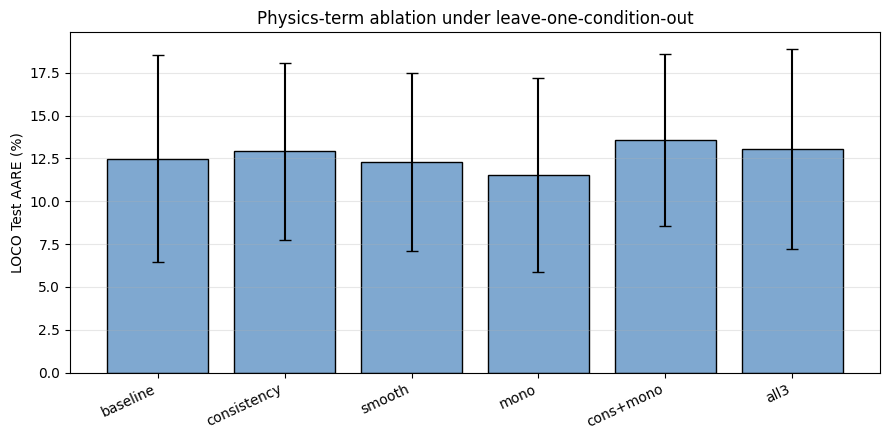

In [13]:
# mean +/- std across (seed x fold) per config
agg = (all_rows.groupby("config")[["r2","rmse","aare"]]
       .agg(["mean","std"]).round(4))
order = [c[0] for c in CONFIGS]
agg = agg.reindex(order)
print("LOCO extrapolation — mean +/- std over seeds x folds")
print(agg)

# paired delta of AARE vs baseline, matched on (seed, fold)
base = all_rows[all_rows.config=="baseline"].set_index(["seed","fold"])["aare"]
print("\nPaired Δ AARE vs baseline  (+ve = improvement):")
for name,_,_ in CONFIGS:
    if name=="baseline": continue
    cur = all_rows[all_rows.config==name].set_index(["seed","fold"])["aare"]
    d = (base - cur).dropna()
    if len(d)>=2:
        try: p = float(_stats.ttest_rel(base.loc[d.index], cur.loc[d.index]).pvalue)
        except Exception: p = float("nan")
        ci = 1.96*d.std()/max(len(d)**0.5,1)
        verdict = "helps" if (d.mean()-ci)>0 else ("hurts" if (d.mean()+ci)<0 else "within noise")
        print(f"  {name:<14} Δ={d.mean():+.2f} ± {d.std():.2f} pp  "
              f"(95%CI ±{ci:.2f}; +ve {int((d>0).sum())}/{len(d)}; p={p:.3f}) -> {verdict}")

# bar figure
fig, ax = plt.subplots(figsize=(9,4.5))
mu = agg[("aare","mean")].values; sd = agg[("aare","std")].values
ax.bar(range(len(order)), mu, yerr=sd, capsize=4, color="#7fa8d0", edgecolor="black")
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=25, ha="right")
ax.set_ylabel("LOCO Test AARE (%)"); ax.set_title("Physics-term ablation under leave-one-condition-out")
ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(f"{CFG.output_dir}/fig_ablation_loco.png", dpi=200, bbox_inches="tight"); plt.show()

## 14 · SCAM Parameter Validation (learned vs classical, inside valid window)

In [14]:
# Train one full-data PGNN(all3) and compare learned Arrhenius params to SCAM where SCAM is valid.
tr, va, te = random_split(CFG.seed)
Fv = prep_fold(tr, va, te)
m_val, _ = train_model(Fv, active=("consistency","smooth","mono"), weighting="uncertainty",
                       seed=CFG.seed, run_name="PGNN-all3/full")
idx_valid = np.where(SCAM_VALID)[0]
_, lp = predict(m_val, Fv, idx_valid)
ev = eps_raw[idx_valid]
print(f"Validation on {len(idx_valid)} SCAM-valid points (T>=250C, eps in [{CFG.scam_eps_min},{CFG.scam_eps_max}])")
print(f"{'param':<6}{'learned mean±std':>22}{'SCAM mean±std':>22}")
for k, div, unit in [("alpha",1,"1/MPa"),("n",1,""),("Q",1e3,"kJ/mol"),("lnA",1,"")]:
    lv = lp[k].flatten()/div
    sv = np.polyval(SCAM_POLY_COEFFS[k], ev)/div
    print(f"{k:<6}{lv.mean():>10.3f}±{lv.std():<8.3f}{sv.mean():>12.3f}±{sv.std():<8.3f} {unit}")
print("\nLiterature anchor: Q for Al hot working ~150-185 kJ/mol (self-diffusion ~142 kJ/mol).")

Validation on 435 SCAM-valid points (T>=250C, eps in [0.05,0.19])
param       learned mean±std         SCAM mean±std
alpha      0.025±0.001          0.019±0.000    1/MPa
n          6.170±0.148          5.633±0.460    
Q        174.670±1.191        157.431±3.416    kJ/mol
lnA       25.666±0.487         25.009±0.839    

Literature anchor: Q for Al hot working ~150-185 kJ/mol (self-diffusion ~142 kJ/mol).


## 15 · How to Extend / Run the Full Study

**To run the real study (not the quick smoke pass):**
1. Set `CFG.quick = False` (restores 500 epochs).
2. In §12, `FOLDS` auto-expands to all hot conditions; widen `SEEDS` (e.g. `[42,1,2,3,4]`).
3. Optionally add `loto_split` folds (leave-one-*temperature*-out) for a harder extrapolation test.
4. Uncomment `scam_legacy` in `CONFIGS` to show the redundant SCAM term within the same ablation.

**Essential design choices (why this is correct):**
- Scalers and the smoothness grid are re-fit **per fold** — no information crosses from test into train.
- Physics terms use **normalized** parameters / input-gradients, so all losses are O(1) and weightable.
- Uncertainty weighting removes per-config λ tuning; fixed-λ mode is available as a cross-check.
- The headline metric is **LOCO extrapolation**, where a real physics prior can actually help — unlike the
  original interpolation split, where it cannot.

**Reading the result:**
- If a physics term's paired Δ is `helps` (CI above 0) under LOCO → genuine, publishable evidence that the
  added physics improves extrapolation.
- If `within noise` → the architecture already captures the physics; report it as an honest negative with the
  parameter-validation (§14) as the positive contribution.